In [ ]:
# %% 
## ------------------------------------------------------------
## 1. Basic setup: repo root + packages + source R/ files
## ------------------------------------------------------------

# Set working directory to the exdqlm repo
setwd("/data/muscat_data/jaguir26/exdqlm")

# Core packages
suppressPackageStartupMessages({
  library(tidyverse)  # includes ggplot2, dplyr, tibble, etc.
})

# Small plotting helpers (lightweight versions of your pipeline ones)
theme_exdqlm <- function(base_size = 11) {
  ggplot2::theme_minimal(base_size = base_size) +
    ggplot2::theme(
      panel.grid.minor = ggplot2::element_blank(),
      plot.title = ggplot2::element_text(face = "bold")
    )
}

qs_ci <- function(x, level = 0.95) {
  p <- (1 - level) / 2
  c(
    lo  = unname(stats::quantile(x, p)),
    med = stats::median(x),
    hi  = unname(stats::quantile(x, 1 - p))
  )
}

plot_beta_forest <- function(beta_draws,
                             term_names = NULL,
                             level = 0.95,
                             top_k = NULL,
                             zero_line = TRUE) {
  stopifnot(is.matrix(beta_draws))
  p <- ncol(beta_draws)
  if (is.null(term_names) || length(term_names) != p) {
    term_names <- paste0("β", seq_len(p))
  }

  qs <- apply(beta_draws, 2, qs_ci, level = level)
  df <- tibble::tibble(
    term   = term_names,
    lo     = qs["lo", ],
    med    = qs["med", ],
    hi     = qs["hi", ],
    width  = hi - lo,
    absmed = abs(med)
  )

  if (!is.null(top_k)) {
    df <- df %>%
      dplyr::arrange(dplyr::desc(absmed)) %>%
      dplyr::slice_head(n = top_k)
  }

  ggplot2::ggplot(df, ggplot2::aes(y = reorder(term, absmed), x = med)) +
    theme_exdqlm() +
    ggplot2::geom_errorbarh(
      ggplot2::aes(xmin = lo, xmax = hi),
      height = 0,
      alpha  = 0.9
    ) +
    ggplot2::geom_point(size = 1.4) +
    {
      if (zero_line) {
        ggplot2::geom_vline(
          xintercept = 0,
          colour     = "red",
          linetype   = "dashed"
        )
      } else ggplot2::geom_blank()
    } +
    ggplot2::labs(
      title = "Readout coefficients: 95% credible intervals",
      subtitle = if (!is.null(top_k)) {
        sprintf("Top %d by |median| • red line at 0", top_k)
      } else {
        "All coefficients • red line at 0"
      },
      x = "value",
      y = NULL
    )
}

# Source ALL R files in R/
r_files <- list.files("R", pattern = "\\.R$", full.names = TRUE)
for (f in r_files) {
  message("Sourcing: ", f)
  source(f)
}

message("Setup done.")

# %% 
## ------------------------------------------------------------
## 2–3. Load series_long.csv, pick p0, build vectors
## ------------------------------------------------------------

series_path <- "results/sim_suite_dlm/series/dlm_ar1V/series_long.csv"

dat_long <- read.csv(series_path)

p0 <- 0.05   # tail quantile for debugging gamma

dat_p <- dat_long %>%
  dplyr::filter(abs(p - p0) < 1e-8) %>%
  dplyr::arrange(t)

# Time series vectors
y_vec  <- dat_p$y
mu_vec <- dat_p$mu
t_vec  <- dat_p$t

cat("n (time points) =", length(y_vec), "\n")

# %% 
## 4. ESN / Q-DESN + exAL spec (no YAML, small-ish reservoir)
## ------------------------------------------------------------

esn_spec <- list(
  D       = 3L,
  n       = c(30L, 30L, 30L),
  n_tilde = c(30L, 30L),
  m       = 30L,
  alpha   = 0.2,
  rho     = rep(0.95, 3L),
  standardize_inputs = FALSE,
  input_bound        = "none",
  win_scale_global   = 1.0,
  win_scale_bias     = 1.0,
  win_scale_lags     = NULL,
  pi_w         = 0.1,
  pi_in        = 0.1,
  washout      = 100L,
  add_bias     = TRUE,
  state_noise_sd = 0.0,
  seed = 123L
)

exal_spec <- list(p0 = p0)

fit_spec <- list(
  method   = "vb",
  max_iter = 500L,   # keep 500 so LDVB actually converges
  tol      = 1e-4
)

# %% 
## 5. Fit a single-quantile Q-DESN + exAL (p0)
## ------------------------------------------------------------

fit_qdesn_exal_single <- function(y, esn_spec, exal_spec, fit_spec) {
  stopifnot(is.numeric(y), length(y) > 0)

  qdesn_fit_vb(
    y   = y,
    p0  = exal_spec$p0,
    D       = esn_spec$D,
    n       = esn_spec$n,
    n_tilde = esn_spec$n_tilde,
    m       = esn_spec$m,
    standardize_inputs = esn_spec$standardize_inputs,
    input_bound        = esn_spec$input_bound,
    win_scale_global   = esn_spec$win_scale_global,
    win_scale_bias     = esn_spec$win_scale_bias,
    win_scale_lags     = esn_spec$win_scale_lags,
    alpha = esn_spec$alpha,
    rho   = esn_spec$rho,
    pi_w         = esn_spec$pi_w,
    pi_in        = esn_spec$pi_in,
    washout      = esn_spec$washout,
    add_bias     = esn_spec$add_bias,
    state_noise_sd = esn_spec$state_noise_sd,
    seed = esn_spec$seed,
    vb_args = list(
      max_iter = fit_spec$max_iter,
      tol      = fit_spec$tol,
      verbose  = TRUE
    )
  )
}

fit_p0 <- fit_qdesn_exal_single(y_vec, esn_spec, exal_spec, fit_spec)

cat("\n--- Q-DESN + exAL fit summary (structural) ---\n")
print(class(fit_p0))
print(names(fit_p0))

fit_exal <- fit_p0$fit
stopifnot(inherits(fit_exal, "exal_vb"))

# Design matrix for β term names
X_mat <- as.matrix(fit_p0$X)

# %% 
## 6. Gamma-related diagnostics: bounds, LD mode, covariance
## ------------------------------------------------------------

cat("\n=== Gamma block diagnostics (p0 =", fit_exal$misc$p0, ") ===\n")

# Bounds used for gamma
g_bounds <- fit_exal$misc$bounds
cat("\n--- Gamma bounds ---\n")
print(g_bounds)

# LD mode in (eta, ell) and derived means
eta_hat  <- fit_exal$qsiggam$eta_hat
ell_hat  <- fit_exal$qsiggam$ell_hat
Sigma_el <- fit_exal$qsiggam$Sigma

cat("\n--- LD mode (eta, ell) ---\n")
print(c(eta_hat = eta_hat, ell_hat = ell_hat))

cat("\n--- Sigma_eta_ell (LD covariance) ---\n")
print(Sigma_el)

cat("\n--- Eigenvalues of Sigma_eta_ell ---\n")
print(eigen(Sigma_el, symmetric = TRUE)$values)

cat("\n--- Approx posterior means (gamma, sigma) from LD block ---\n")
print(c(
  gamma_mean = fit_exal$qsiggam$gamma_mean,
  sigma_mean = fit_exal$qsiggam$sigma_mean
))

# %% 
## 7. Posterior draws for (gamma, sigma, beta) and summaries
## ------------------------------------------------------------

set.seed(123)
draws <- exal_vb_posterior_draws(fit_exal, nd = 5000L)

gamma_draws <- draws$gamma
sigma_draws <- draws$sigma
beta_draws  <- draws$beta  # matrix (nd × p)

cat("\n--- Gamma posterior summary (5000 draws) ---\n")
gamma_summary <- c(
  mean = mean(gamma_draws),
  sd   = sd(gamma_draws),
  q05  = quantile(gamma_draws, 0.05),
  q25  = quantile(gamma_draws, 0.25),
  q50  = quantile(gamma_draws, 0.50),
  q75  = quantile(gamma_draws, 0.75),
  q95  = quantile(gamma_draws, 0.95)
)
print(gamma_summary)

cat("\nrange(gamma_draws):\n")
print(range(gamma_draws))

cat("\n--- Sigma posterior summary (for context) ---\n")
sigma_summary <- c(
  mean = mean(sigma_draws),
  sd   = sd(sigma_draws),
  q05  = quantile(sigma_draws, 0.05),
  q25  = quantile(sigma_draws, 0.25),
  q50  = quantile(sigma_draws, 0.50),
  q75  = quantile(sigma_draws, 0.75),
  q95  = quantile(sigma_draws, 0.95)
)
print(sigma_summary)

# Extra: 95% credible intervals for titles/subtitles
gamma_ci_95 <- quantile(gamma_draws, c(0.025, 0.975))
sigma_ci_95 <- quantile(sigma_draws, c(0.025, 0.975))

# For plotting ranges: 0.001 and 0.999 quantiles
gamma_q01_99 <- quantile(gamma_draws, c(0.001, 0.999))
sigma_q01_99 <- quantile(sigma_draws, c(0.001, 0.999))

# %% 
## 8. Plots: gamma & sigma histograms + ELBO trace (post-burn)
## ------------------------------------------------------------

elbo <- fit_exal$misc$elbo
cat("\n--- ELBO trace info ---\n")
cat("length(elbo) =", length(elbo), "\n")
if (length(elbo) > 0L) {
  cat("last 5 ELBO values:\n")
  print(tail(elbo, 5))
}


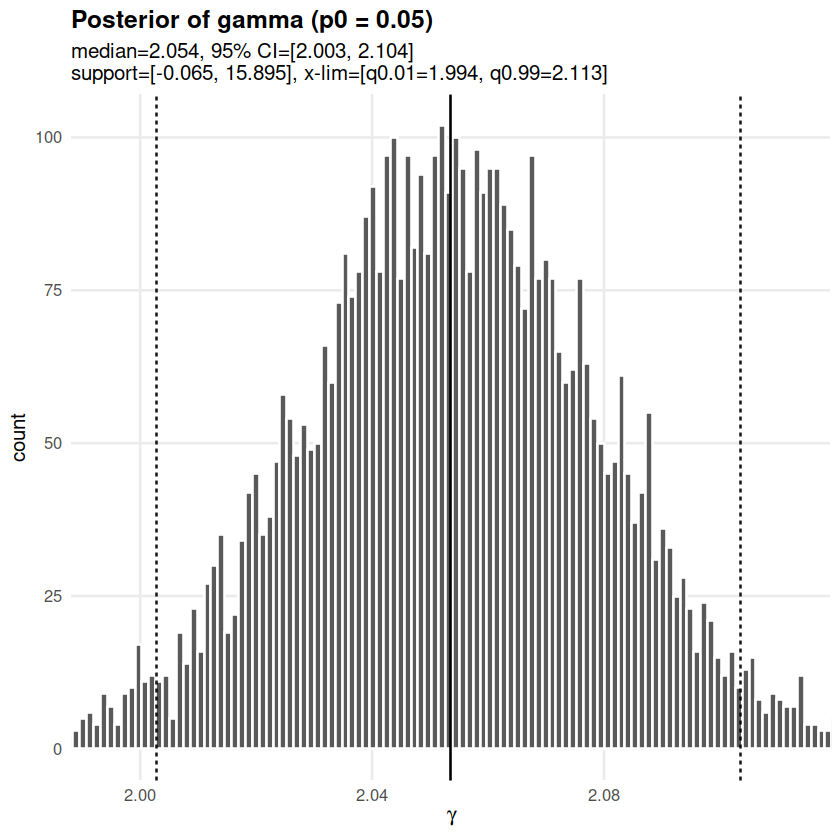

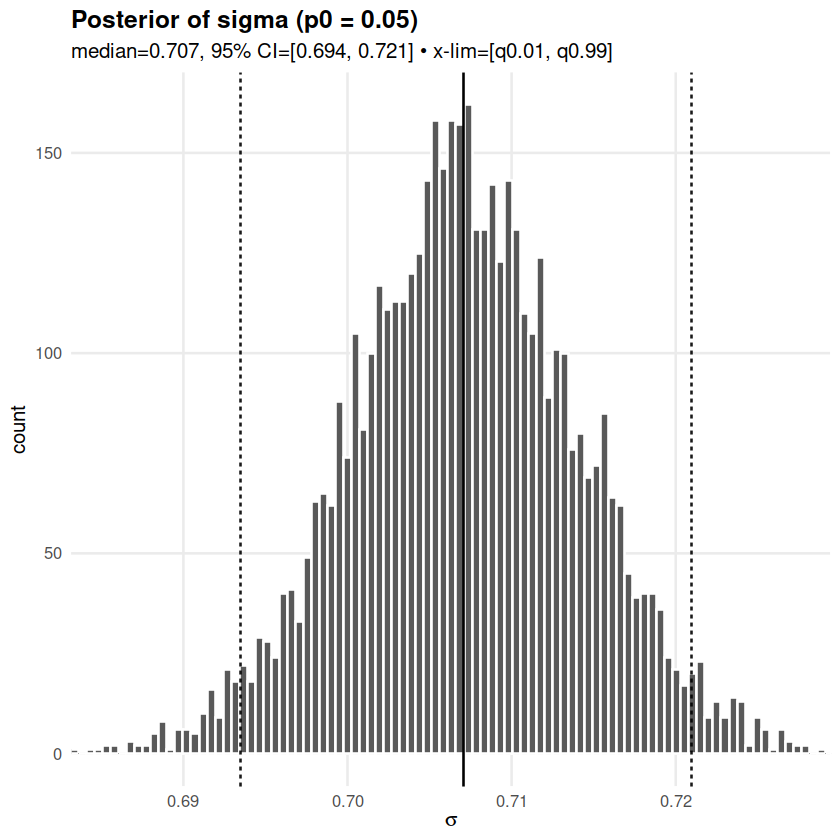

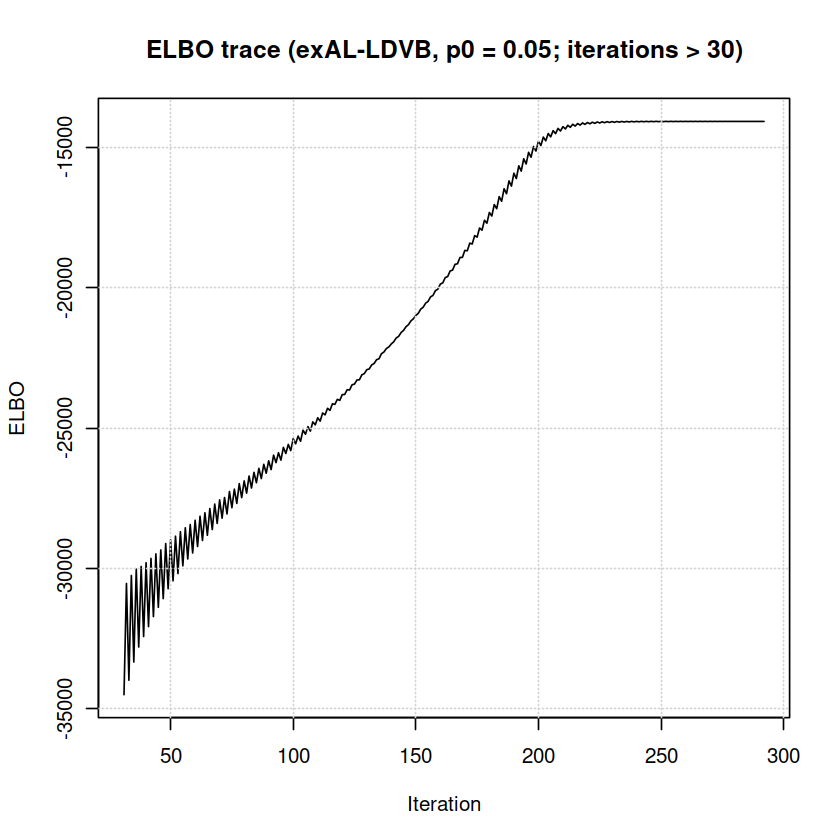

In [ ]:
## 8a) Gamma posterior histogram (with CI, support, truncated x-range)
gamma_df <- tibble::tibble(gamma = gamma_draws)

# 0.01 and 0.99 quantiles of the gamma draws (for zoomed x-axis)
gamma_qs <- stats::quantile(gamma_draws, probs = c(0.01, 0.99))
g_lo <- unname(gamma_qs[1])
g_hi <- unname(gamma_qs[2])

g_gamma_hist <- ggplot2::ggplot(gamma_df, ggplot2::aes(x = gamma)) +
  theme_exdqlm(base_size = 12) +
  ggplot2::geom_histogram(
    binwidth = (g_hi - g_lo) / 100,  # ~30 bins over [q0.01, q0.99]
    color    = "white"
  ) +
  # median and 95% CI
  ggplot2::geom_vline(
    xintercept = stats::median(gamma_draws),
    linetype   = "solid"
  ) +
  ggplot2::geom_vline(
    xintercept = gamma_ci_95,
    linetype   = "dashed",
    alpha      = 0.9
  ) +
  # reference: gamma = 0
  ggplot2::geom_vline(
    xintercept = 0,
    colour     = "red",
    linetype   = "dashed"
  ) +
  # support bounds
  ggplot2::geom_vline(
    xintercept = g_bounds["L"],
    colour     = "blue",
    linetype   = "dotted"
  ) +
  ggplot2::geom_vline(
    xintercept = g_bounds["U"],
    colour     = "blue",
    linetype   = "dotted"
  ) +
  # zoom x-axis to [q0.01, q0.99] without dropping data
  ggplot2::coord_cartesian(
    xlim = c(g_lo, g_hi)
  ) +
  ggplot2::labs(
    title = sprintf("Posterior of gamma (p0 = %.2f)", p0),
    subtitle = sprintf(
      "median=%.3f, 95%% CI=[%.3f, %.3f]\nsupport=[%.3f, %.3f], x-lim=[q0.01=%.3f, q0.99=%.3f]",
      stats::median(gamma_draws),
      gamma_ci_95[1], gamma_ci_95[2],
      g_bounds["L"], g_bounds["U"],
      g_lo, g_hi
    ),
    x = expression(gamma),
    y = "count"
  )

print(g_gamma_hist)


## 8b) Sigma posterior histogram (with CI, truncated x-range)
sigma_df <- tibble::tibble(sigma = sigma_draws)

g_sigma_hist <- ggplot2::ggplot(sigma_df, ggplot2::aes(x = sigma)) +
  theme_exdqlm(base_size = 12) +
  ggplot2::geom_histogram(bins = 100, color = "white") +
  ggplot2::geom_vline(
    xintercept = median(sigma_draws),
    linetype   = "solid"
  ) +
  ggplot2::geom_vline(
    xintercept = sigma_ci_95,
    linetype   = "dashed",
    alpha      = 0.9
  ) +
  ggplot2::coord_cartesian(
    xlim = sigma_q01_99
  ) +
  ggplot2::labs(
    title = sprintf("Posterior of sigma (p0 = %.2f)", p0),
    subtitle = sprintf(
      "median=%.3f, 95%% CI=[%.3f, %.3f] • x-lim=[q0.01, q0.99]",
      median(sigma_draws),
      sigma_ci_95[1], sigma_ci_95[2]
    ),
    x = expression(sigma),
    y = "count"
  )

print(g_sigma_hist)

## 8c) ELBO trace (only iterations after burn-in)
burn_in <- 30L
if (length(elbo) > burn_in) {
  idx_keep <- which(seq_along(elbo) > burn_in)
  plot(
    idx_keep, elbo[idx_keep],
    type = "l",
    xlab = "Iteration",
    ylab = "ELBO",
    main = sprintf(
      "ELBO trace (exAL-LDVB, p0 = %.2f; iterations > %d)",
      p0, burn_in
    )
  )
  grid()
} else {
  warning("ELBO vector shorter than burn_in; plotting all iterations instead.")
  plot(
    seq_along(elbo), elbo,
    type = "l",
    xlab = "Iteration",
    ylab = "ELBO",
    main = sprintf("ELBO trace (exAL-LDVB, p0 = %.2f)", p0)
  )
  grid()
}

Warning message:
“`geom_errobarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead.”
`height` was translated to `width`.
`height` was translated to `width`.


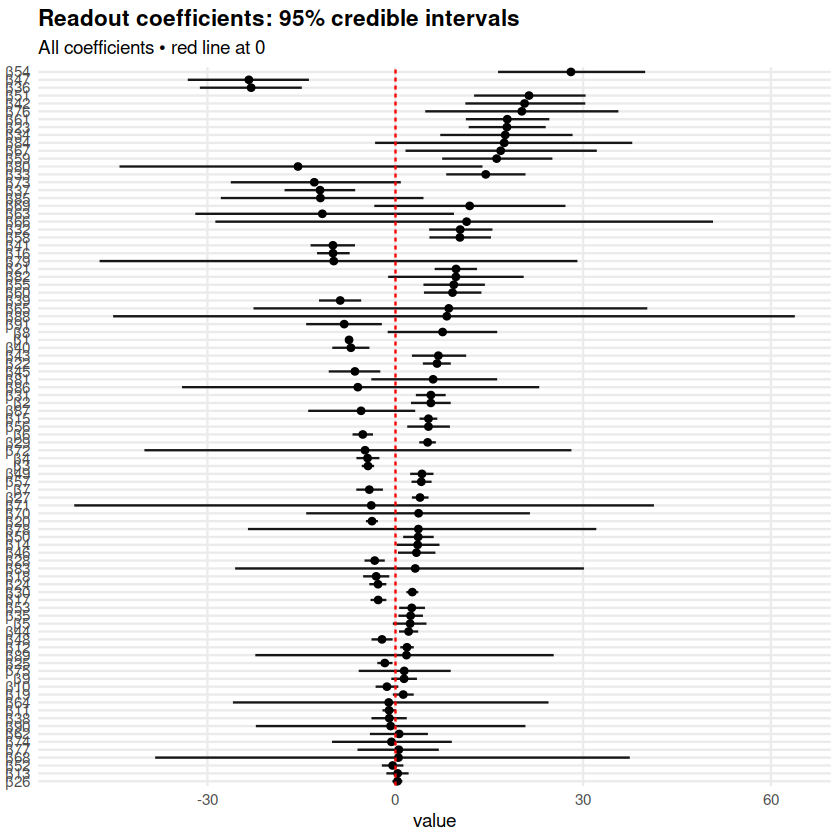


=== Gamma / sigma / beta / ELBO diagnostics script finished. ===


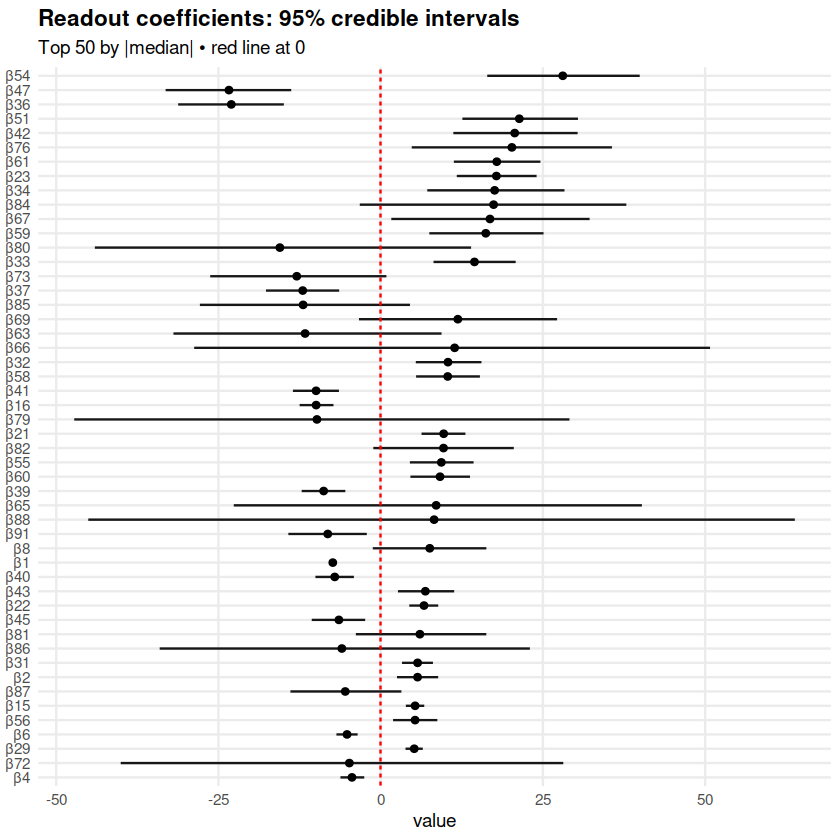

In [3]:
# %% 
## 9. β coefficient forest plots (all + top-K)
## ------------------------------------------------------------

if (!is.null(beta_draws) && is.matrix(beta_draws)) {
  term_names <- colnames(X_mat)
  if (is.null(term_names)) {
    term_names <- paste0("β", seq_len(ncol(beta_draws)))
  }

  # All coefficients
  g_beta_all <- plot_beta_forest(
    beta_draws,
    term_names = term_names,
    top_k      = NULL
  )

  # Top K by |median|
  K <- min(50L, ncol(beta_draws))
  g_beta_top <- plot_beta_forest(
    beta_draws,
    term_names = term_names,
    top_k      = K
  )

  print(g_beta_all)
  print(g_beta_top)
} else {
  warning("beta_draws is NULL or not a matrix; skipping beta forest plots.")
}

cat("\n=== Gamma / sigma / beta / ELBO diagnostics script finished. ===\n")
